# Capstone Project: Nutrition Dataset
**Tim Capstone**:CC26-PSU399

## Menentukan Pertanyaan Bisnis

1. Bagaimana distribusi kandungan kalori dan makronutrien (lemak, karbohidrat, protein) dari berbagai jenis makanan, dan makanan apa saja yang menduduki peringkat teratas serta terbawah untuk masing-masing nutrisi?
2. Nutrisi mana (lemak, karbohidrat, atau protein) yang paling berkontribusi atau memiliki korelasi terkuat terhadap tingginya jumlah kalori suatu makanan, dan apakah ada menu makanan yang tinggi nutrisi namun tetap rendah kalori?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
# Membaca file csv data hasil scraping nutrisi pada makanan
nutrisi = pd.read_csv('/content/hasil_gizi.csv')
nutrisi.head()

,nama,kalori,lemak,karbohidrat,protein
0,Nasi Putih,129,"0,28g","27,9g","2,66g"
1,Nasi Merah,110,"0,89g","22,78g","2,56g"
2,Lontong,130,"0,2g","28,58g","2,49g"
3,Lontong Sayur,357,"8,39g","59,1g","11,11g"
4,Ketupat,160,"2,42g","30,36g","3,27g"


**Insight**:
1. Profil Makanan Pokok Murni: Nasi Putih, Nasi Merah, Lontong, dan Ketupat memiliki karakteristik dasar yang mirip, yaitu didominasi oleh karbohidrat (berkisar antara 22,78g hingga 30,36g) dengan kandungan lemak yang sangat rendah ($< 3\text{g}$). Di antara kelompok ini, Nasi Merah merupakan opsi paling rendah kalori (110 kkal) sehingga paling ideal untuk menu diet.
2. Efek Hidangan Campuran: Ketika makanan pokok dikembangkan menjadi sajian lengkap seperti Lontong Sayur, nilai gizinya melonjak drastis. Kalorinya melesat hingga 357 kkal (hampir 3 kali lipat dari nasi putih biasa) yang dipicu oleh kenaikan signifikan pada komponen lemak (8,39g) dan protein (11,11g) akibat tambahan kuah santan serta lauk pauknya.

### Assessing Data

In [ ]:
# Mengetahui tipe data pada tiap-tiap fitur
nutrisi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nama         118 non-null    object
 1   kalori       118 non-null    int64 
 2   lemak        118 non-null    object
 3   karbohidrat  118 non-null    object
 4   protein      118 non-null    object
dtypes: int64(1), object(4)
memory usage: 4.7+ KB


In [ ]:
# Mengecek apakah terdapat missing value pada data
nutrisi.isna().sum()

,0
nama,0
kalori,0
lemak,0
karbohidrat,0
protein,0


In [ ]:
# Mengecek apakah terdapat baris yang terduplikasi pada data
print('Jumlah duplikasi: ',nutrisi.duplicated().sum())

Jumlah duplikasi:  3


In [ ]:
# Mengetahui statistik deskriptif data pada tiap-tiap fitur
nutrisi.describe()

,kalori
count,118.000000
mean,203.101695
std,170.854333
min,15.000000
25%,96.500000
50%,157.000000
75%,276.000000
max,980.000000


**Insight**:
1. Karakteristik Teknis & Validasi Data (Data Quality)
*  Kelengkapan Data (No Missing Values): Dataset ini memiliki total 118 baris entri data (RangeIndex: 118 entries). Kabar baiknya, fungsi isna().sum() menunjukkan angka 0 di semua fitur, yang berarti tidak ada data kosong (missing value) sama sekali pada seluruh kolom.
*   Kelemahan Tipe Data: Output fungsi info() mengonfirmasi masalah pada tipe data makronutrisi. Hanya kolom kalori yang terdeteksi sebagai numerik (int64). Sementara itu, kolom lemak, karbohidrat, dan protein bertipe object (string/teks). Dampaknya terlihat jelas pada fungsi nutrisi.describe(), di mana Pandas hanya mampu menampilkan ringkasan statistik untuk kolom kalori.
* Redundansi Data (Duplikasi): Deteksi baris kembar menunjukkan terdapat 3 data yang terduplikasi di dalam dataset.

2. Ringkasan Statistik Kalori (Statistical Insight)
* Rata-rata Kalori: Menu makanan dalam dataset ini rata-rata memiliki energi sebesar 203,1 kkal (mean), dengan variasi sebaran data yang cukup lebar karena standar deviasinya mencapai 170,85 kkal.
* Rentang Ekstrem (Min-Max): Terdapat variasi menu yang sangat kontras, mulai dari makanan dengan kalori sangat rendah sebesar 15 kkal (min) hingga makanan padat energi yang mencapai 980 kkal (max).
* Distribusi Kuartil: Setengah dari total menu makanan (50% / median) memiliki kalori di bawah 157 kkal, sementara 25% menu makanan dengan kalori tertinggi berada di rentang 276 kkal hingga 980 kkal.

## Cleaning Data

In [ ]:
# Mengganti kolom Lemak, Karbohidrat, dan Protein menjadi numerik dengan menghilangkan huruf 'g'
columns_to_convert = ['lemak', 'karbohidrat', 'protein']

for col in columns_to_convert:
    nutrisi[col] = nutrisi[col].astype(str).str.replace('g', '', regex=False).str.replace(',', '.', regex=False)
    nutrisi[col] = pd.to_numeric(nutrisi[col])

nutrisi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nama         118 non-null    object 
 1   kalori       118 non-null    int64  
 2   lemak        118 non-null    float64
 3   karbohidrat  118 non-null    float64
 4   protein      118 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 4.7+ KB


In [ ]:
# Mengganti nama makanan 'Nila (Ikan) (Dimasak, Panas Kering)' menjadi 'Ikan Nila Goreng'
nutrisi['nama'] = nutrisi['nama'].replace('Nila (Ikan) (Dimasak, Panas Kering)', 'Ikan Nila Goreng')

In [ ]:
# Mengganti sel 'Daging Ayam (Panggang, Bakar, Dimasak)' menjadi 'Ayam Bakar' dan 'Ayam Panggang'
indices_to_replace = nutrisi[nutrisi['nama'] == 'Daging Ayam (Panggang, Bakar, Dimasak)'].index

if len(indices_to_replace) >= 1:
    nutrisi.loc[indices_to_replace[0], 'nama'] = 'Ayam Panggang'
if len(indices_to_replace) >= 2:
    nutrisi.loc[indices_to_replace[1], 'nama'] = 'Ayam Bakar'

modified_indices = nutrisi[nutrisi['nama'].isin(['Ayam Panggang', 'Ayam Bakar'])].index
display(nutrisi.loc[modified_indices])

,nama,kalori,lemak,karbohidrat,protein
20,Ayam Panggang,167,6.63,0.0,25.01
21,Ayam Bakar,167,6.63,0.0,25.01


In [ ]:
# Mengganti nama makanan 'Mi Goreng' menjadi 'Indomie Goreng'
nutrisi['nama'] = nutrisi['nama'].replace('Mi Goreng', 'Indomie Goreng')

# Mengganti nama makanan 'Rasa Ayam Bawang' menjadi 'Indomie Ayam Bawang'
nutrisi['nama'] = nutrisi['nama'].replace('Rasa Ayam Bawang', 'Indomie Ayam Bawang')

# Mengganti nama makanan 'Rasa Soto Mie' menjadi 'Indomie Soto'
nutrisi['nama'] = nutrisi['nama'].replace('Rasa Soto Mie', 'Indomie Soto')

# Mengganti nama makanan 'Mi Goreng Aceh' menjadi 'Indomie Goreng Aceh'
nutrisi['nama'] = nutrisi['nama'].replace('Mi Goreng Aceh', 'Indomie Goreng Aceh')

# Mengganti nama makanan 'Kari Ayam' menjadi 'Indomie Kari Ayam'
nutrisi.loc[(nutrisi['nama'] == 'Kari Ayam') & (nutrisi['kalori'] == 330), 'nama'] = 'Indomie Kari Ayam'

# Mengganti nama makanan 'Mi Goreng Rendang' menjadi 'Indomie Goreng Rendang'
nutrisi['nama'] = nutrisi['nama'].replace('Mi Goreng Rendang', 'Indomie Goreng Rendang')

# Mengganti nama makanan 'Mi Goreng Jumbo' menjadi 'Indomie Goreng Jumbo'
nutrisi['nama'] = nutrisi['nama'].replace('Mi Goreng Jumbo', 'Indomie Goreng Jumbo')

# Mengganti nama makanan 'Mie Nyemek Bangladesh' menjadi 'Indomie Nyemek Bangladesh'
nutrisi['nama'] = nutrisi['nama'].replace('Mie Nyemek Bangladesh', 'Indomie Nyemek Bangladesh')

# Mengganti nama makanan 'Mi Goreng Ayam Geprek' menjadi 'Indomie Goreng Ayam Geprek'
nutrisi['nama'] = nutrisi['nama'].replace('Mi Goreng Ayam Geprek', 'Indomie Goreng Ayam Geprek')

# Mengganti nama makanan 'Mie Rebus' menjadi 'Indomie Rebus'
nutrisi['nama'] = nutrisi['nama'].replace('Mie Rebus', 'Indomie Rebus')

In [ ]:
# Mengecek kembali baris duplikasi setelah penggantian nama makanan
print('Jumlah duplikasi: ',nutrisi.duplicated().sum())

Jumlah duplikasi:  2


In [ ]:
# Mengatasi baris duplikasi
nutrisi = nutrisi.drop_duplicates()
print('Jumlah duplikasi: ',nutrisi.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
# Mengecek statistik deskriptif tiap-tiap fitur setelah merubah tipe data
nutrisi.describe()

,kalori,lemak,karbohidrat,protein
count,116.000000,116.000000,116.000000,116.000000
mean,195.387931,8.593534,18.197328,11.253103
std,155.786854,8.020314,21.081767,9.666239
min,15.000000,0.200000,0.000000,0.000000
25%,94.500000,2.680000,2.387500,2.907500
50%,153.000000,6.630000,9.540000,7.600000
75%,269.250000,12.035000,28.070000,17.837500
max,980.000000,55.000000,95.000000,44.110000


### Insight:
1. **Validasi & Kualitas Data**: Tahap *data cleaning* berhasil mengonversi fitur makronutrisi (`lemak`, `karbohidrat`, `protein`) menjadi tipe data `float64` serta mengeliminasi baris duplikat, sehingga menyisakan 116 entri data yang valid dan siap dianalisis.
2. **Profil Nutrisi Makro**: Berdasarkan ringkasan statistik, menu makanan dalam dataset secara rata-rata didominasi oleh karbohidrat (18,19g), disusul protein (11,25g), dan lemak (8,59g), dengan rata-rata kalori sebesar 195,38 kkal.
3. **Anomali/Data Ekstrem**: Distribusi data menunjukkan adanya variasi makanan yang sangat kontras. Terdeteksi adanya menu makanan tinggi kalori (hingga 980 kkal) yang dipicu oleh kandungan lemak (max: 55g) atau karbohidrat (max: 95g) yang sangat ekstrem di atas rata-rata.

## Exploratory Data Analysis (EDA)

### Mengetahui 10 makanan yang memiliki kalori terbanyak

In [ ]:
print('Makanan dengan Kalori Paling Banyak:')
display(nutrisi.nlargest(10, 'kalori'))

Makanan dengan Kalori Paling Banyak:


,nama,kalori,lemak,karbohidrat,protein
11,Nasi Padang Rendang,980,55.00,95.00,28.00
12,Nasi Padang Ayam Bakar,689,24.08,72.06,44.11
81,Bakmi Goreng,610,17.00,88.00,27.00
105,Indomie Goreng Jumbo,540,23.00,74.00,11.00
82,Bakmi Kuah Cha Cha,480,20.00,56.00,19.00
32,Bebek Bakar,471,38.84,0.00,28.13
88,Bihun Goreng Ayam,455,17.04,54.79,17.73
104,Indomie Goreng Rendang,440,20.00,57.00,8.00
101,Indomie Goreng Aceh,430,19.00,55.00,9.00
85,Mie Ayam,421,18.74,46.21,16.70


### Mengetahui 10 makanan yang memiliki kalori terendah

In [ ]:
print('Makanan dengan Kalori Paling Rendah:')
display(nutrisi.nsmallest(10, 'kalori'))

Makanan dengan Kalori Paling Rendah:


,nama,kalori,lemak,karbohidrat,protein
108,Sambal Goreng,15,0.41,1.56,1.37
112,Sambal Terasi,15,0.50,2.00,0.00
114,Sambal Matah,21,1.54,1.79,0.44
69,Tahu Bacem,24,1.47,1.09,1.90
111,Sambal Rawit,25,1.50,3.00,1.00
117,Sambal Geprek,25,1.50,2.00,0.00
115,Sambal Bawang,30,2.50,1.00,0.00
34,Sate Kambing,32,2.11,0.72,2.84
29,Sate Ayam,34,2.22,0.73,2.93
66,Tempe Goreng,34,2.28,1.79,2.00


### Mengetahui 10 makanan yang tinggi protein (> 10 gram) tetapi sangat rendah lemak (< 5 gram) untuk target kalori harian

In [ ]:
protein_threshold = 10
fat_threshold = 5

print(f"Ambang batas protein (di atas): {protein_threshold}g")
print(f"Ambang batas lemak (di bawah): {fat_threshold}g")

high_protein_low_fat_low_calorie = nutrisi[
    (nutrisi['protein'] > protein_threshold) &
    (nutrisi['lemak'] < fat_threshold)
].sort_values(by=['protein', 'lemak'], ascending=[False, True])

print('\nMakanan yang Tinggi Protein dan Rendah Lemak:')
display(high_protein_low_fat_low_calorie.head(10))

Ambang batas protein (di atas): 10g
Ambang batas lemak (di bawah): 5g

Makanan yang Tinggi Protein dan Rendah Lemak:


,nama,kalori,lemak,karbohidrat,protein
62,Ikan Asin,195,1.59,0.00,42.16
51,Ikan Tongkol Balado,202,4.68,2.80,35.21
50,Ikan Nila Goreng,128,2.65,0.00,26.15
43,Ikan Bawal Goreng,113,2.69,0.00,20.78
64,Kepiting,101,1.76,0.00,20.03
42,Lele Goreng,105,2.85,0.00,18.47
53,Pepes Tongkol,105,1.27,7.10,15.93
54,Cumi Goreng,125,2.17,9.90,15.13
40,Gulai Daging Sapi,109,4.63,3.02,13.20


### Insight:

1. **Pola Hidangan Tinggi Kalori (Energi Padat)**: Olahan kuliner berat seperti *Nasi Padang Rendang* menempati rating kalori tertinggi (980 kkal) yang dipicu oleh kombinasi masif karbohidrat (95g) dan lemak jenuh (55g). Kelompok mi goreng dan mi instan secara konsisten menjadi kontributor kalori tinggi berikutnya pada rentang 420-610 kkal.
2. **Karakteristik Menu Kalori Rendah**: Menu dengan kalori terkecil didominasi oleh variasi sambal lokal (15-30 kkal) karena batasan volume konsumsinya. Selain itu, nilai kalori rendah pada *Sate Ayam* dan *Sate Kambing* (32-34 kkal) mengindikasikan bahwa basis data ini dihitung menggunakan satuan per tusuk, bukan per porsi saji standar.
3. **Pilihan Optimal untuk Diet (High-Protein, Low-Fat)**: Melalui teknik filtrasi bersyarat, sektor *seafood* dan perikanan (*Ikan Asin*, *Ikan Tongkol Balado*, *Ikan Nila*, dan *Kepiting*) terbukti menjadi komoditas makanan paling ideal untuk pemenuhan gizi seimbang. Kelompok ini mampu menyuplai protein tinggi (hingga >40g) dengan kontribusi lemak yang sangat minimal (<5g), menjadikannya referensi utama untuk penyusunan target kalori harian yang sehat.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi kandungan kalori dan makronutrien (lemak, karbohidrat, protein) dari berbagai jenis makanan, dan makanan apa saja yang menduduki peringkat teratas serta terbawah untuk masing-masing nutrisi?

### 1. Distribusi Kalori dan Makronutrien (Dengan Visualisasi)

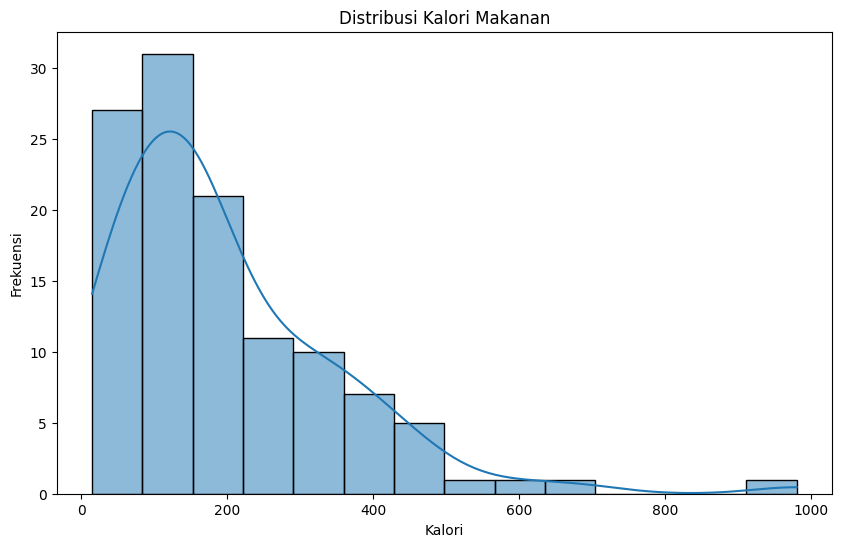

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(nutrisi['kalori'], kde=True)
plt.title('Distribusi Kalori Makanan')
plt.xlabel('Kalori')
plt.ylabel('Frekuensi')
plt.show()

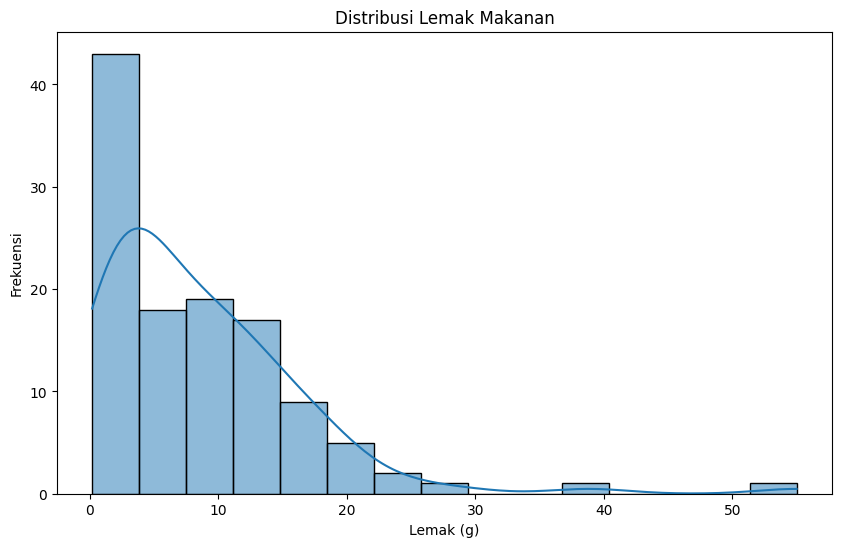

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(nutrisi['lemak'], kde=True)
plt.title('Distribusi Lemak Makanan')
plt.xlabel('Lemak (g)')
plt.ylabel('Frekuensi')
plt.show()

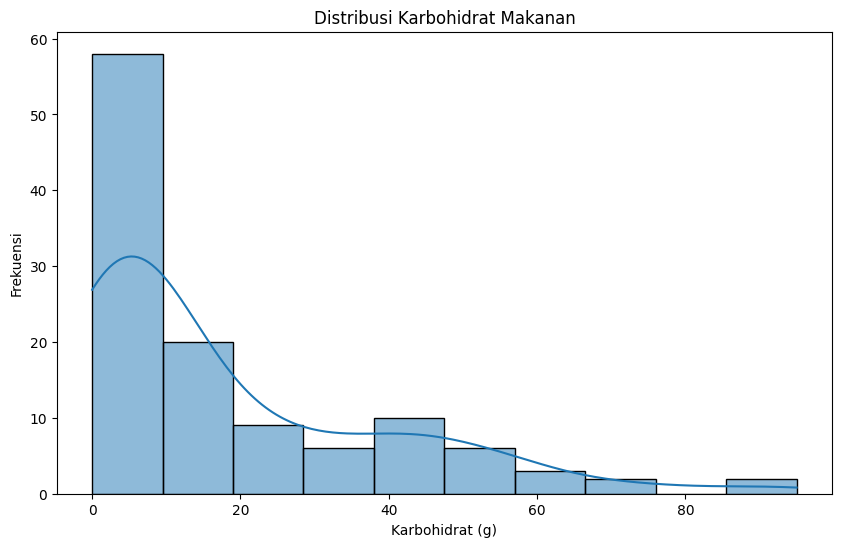

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(nutrisi['karbohidrat'], kde=True)
plt.title('Distribusi Karbohidrat Makanan')
plt.xlabel('Karbohidrat (g)')
plt.ylabel('Frekuensi')
plt.show()

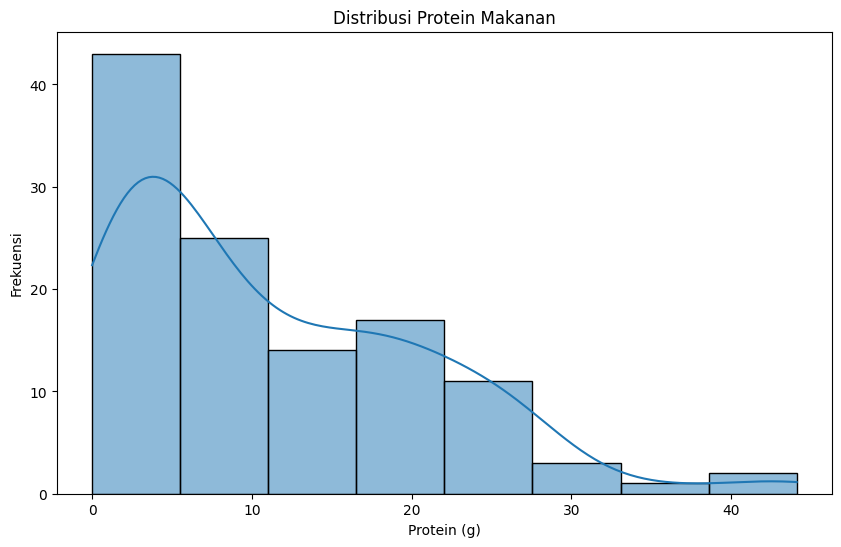

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(nutrisi['protein'], kde=True)
plt.title('Distribusi Protein Makanan')
plt.xlabel('Protein (g)')
plt.ylabel('Frekuensi')
plt.show()

### Insight:

1. **Karakteristik Distribusi (Right-Skewed)**: Keempat grafik (`kalori`, `lemak`, `karbohidrat`, dan `protein`) secara konsisten menunjukkan pola distribusi menceng ke kanan (*right-skewed*). Ini membuktikan bahwa mayoritas menu makanan yang dikumpulkan didominasi oleh makanan ringan, pelengkap, atau lauk dengan profil nutrisi rendah hingga moderat, sementara hidangan berat dengan gizi padat bertindak sebagai pencilan (*outlier*).
2. **Pola Pemusatan Data (Modus)**:
   * **Kalori**: Mayoritas makanan berpusat pada energi rendah-sedang di kisaran **100 - 200 kkal**.
   * **Lemak & Protein**: Sebagian besar menu memiliki kandungan lemak dan protein yang sangat minimal, menumpuk pada rentang **0 - 5 gram**.
   * **Karbohidrat**: Frekuensi tertinggi berada pada rentang **0 - 10 gram**, namun terdapat pola fluktuasi unik (*secondary peak*) di sekitar **40 gram** yang menunjukkan keberadaan kelompok hidangan berbasis karbohidrat tinggi (seperti nasi atau mi).
3. **Identifikasi Nilai Ekstrem (Outliers)**: Grafik visualisasi sukses memetakan letak nilai maksimum yang sempat ditemukan pada analisis deskriptif sebelumnya. Terlihat jelas adanya menu ekstrem di ujung kanan masing-masing histogram, seperti kalori yang mendekati **1000 kkal**, lemak hingga **55 gram**, karbohidrat mencapai **95 gram**, dan protein tertinggi di kisaran **40-44 gram**.

#### Makanan dengan Kalori Tertinggi dan Terendah

In [ ]:
print('Makanan dengan Kalori Tertinggi:')
display(nutrisi.nlargest(10, 'kalori'))

print('\nMakanan dengan Kalori Terendah:')
display(nutrisi.nsmallest(10, 'kalori'))

Makanan dengan Kalori Tertinggi:


,nama,kalori,lemak,karbohidrat,protein
11,Nasi Padang Rendang,980,55.00,95.00,28.00
12,Nasi Padang Ayam Bakar,689,24.08,72.06,44.11
81,Bakmi Goreng,610,17.00,88.00,27.00
105,Indomie Goreng Jumbo,540,23.00,74.00,11.00
82,Bakmi Kuah Cha Cha,480,20.00,56.00,19.00
32,Bebek Bakar,471,38.84,0.00,28.13
88,Bihun Goreng Ayam,455,17.04,54.79,17.73
104,Indomie Goreng Rendang,440,20.00,57.00,8.00
101,Indomie Goreng Aceh,430,19.00,55.00,9.00
85,Mie Ayam,421,18.74,46.21,16.70



Makanan dengan Kalori Terendah:


,nama,kalori,lemak,karbohidrat,protein
108,Sambal Goreng,15,0.41,1.56,1.37
112,Sambal Terasi,15,0.50,2.00,0.00
114,Sambal Matah,21,1.54,1.79,0.44
69,Tahu Bacem,24,1.47,1.09,1.90
111,Sambal Rawit,25,1.50,3.00,1.00
117,Sambal Geprek,25,1.50,2.00,0.00
115,Sambal Bawang,30,2.50,1.00,0.00
34,Sate Kambing,32,2.11,0.72,2.84
29,Sate Ayam,34,2.22,0.73,2.93
66,Tempe Goreng,34,2.28,1.79,2.00


#### Makanan dengan Lemak Tertinggi dan Terendah

In [ ]:
print('Makanan dengan Lemak Tertinggi:')
display(nutrisi.nlargest(10, 'lemak'))

print('\nMakanan dengan Lemak Terendah:')
display(nutrisi.nsmallest(10, 'lemak'))

Makanan dengan Lemak Tertinggi:


,nama,kalori,lemak,karbohidrat,protein
11,Nasi Padang Rendang,980,55.00,95.00,28.00
32,Bebek Bakar,471,38.84,0.00,28.13
31,Bebek Goreng,337,28.44,4.32,15.39
12,Nasi Padang Ayam Bakar,689,24.08,72.06,44.11
105,Indomie Goreng Jumbo,540,23.00,74.00,11.00
82,Bakmi Kuah Cha Cha,480,20.00,56.00,19.00
104,Indomie Goreng Rendang,440,20.00,57.00,8.00
101,Indomie Goreng Aceh,430,19.00,55.00,9.00
107,Indomie Goreng Ayam Geprek,410,19.00,52.00,8.00
85,Mie Ayam,421,18.74,46.21,16.70



Makanan dengan Lemak Terendah:


,nama,kalori,lemak,karbohidrat,protein
2,Lontong,130,0.20,28.58,2.49
10,Nasi Kuning,150,0.27,32.96,2.99
0,Nasi Putih,129,0.28,27.90,2.66
72,Sayur Bening Bayam,36,0.37,7.64,1.79
75,Sayur Nangka,57,0.40,11.30,2.00
108,Sambal Goreng,15,0.41,1.56,1.37
112,Sambal Terasi,15,0.50,2.00,0.00
78,Lalapan,46,0.70,9.75,2.05
1,Nasi Merah,110,0.89,22.78,2.56
53,Pepes Tongkol,105,1.27,7.10,15.93


#### Makanan dengan Karbohidrat Tertinggi dan Terendah

In [ ]:
print('Makanan dengan Karbohidrat Tertinggi:')
display(nutrisi.nlargest(10, 'karbohidrat'))

print('\nMakanan dengan Karbohidrat Terendah:')
display(nutrisi.nsmallest(10, 'karbohidrat'))

Makanan dengan Karbohidrat Tertinggi:


,nama,kalori,lemak,karbohidrat,protein
11,Nasi Padang Rendang,980,55.00,95.00,28.00
81,Bakmi Goreng,610,17.00,88.00,27.00
105,Indomie Goreng Jumbo,540,23.00,74.00,11.00
12,Nasi Padang Ayam Bakar,689,24.08,72.06,44.11
17,Bubur Manado,349,7.63,61.67,10.51
3,Lontong Sayur,357,8.39,59.10,11.11
104,Indomie Goreng Rendang,440,20.00,57.00,8.00
82,Bakmi Kuah Cha Cha,480,20.00,56.00,19.00
101,Indomie Goreng Aceh,430,19.00,55.00,9.00
88,Bihun Goreng Ayam,455,17.04,54.79,17.73



Makanan dengan Karbohidrat Terendah:


,nama,kalori,lemak,karbohidrat,protein
20,Ayam Panggang,167,6.63,0.0,25.01
21,Ayam Bakar,167,6.63,0.0,25.01
32,Bebek Bakar,471,38.84,0.0,28.13
42,Lele Goreng,105,2.85,0.0,18.47
43,Ikan Bawal Goreng,113,2.69,0.0,20.78
44,Ikan Bawal Bakar,144,5.04,0.0,23.00
46,Ikan Gurame,125,5.49,0.0,17.48
48,Ikan Patin Goreng,126,6.55,0.0,15.75
50,Ikan Nila Goreng,128,2.65,0.0,26.15
62,Ikan Asin,195,1.59,0.0,42.16


#### Makanan dengan Protein Tertinggi dan Terendah

In [ ]:
print('Makanan dengan Protein Tertinggi:')
display(nutrisi.nlargest(10, 'protein'))

print('\nMakanan dengan Protein Terendah:')
display(nutrisi.nsmallest(10, 'protein'))

Makanan dengan Protein Tertinggi:


,nama,kalori,lemak,karbohidrat,protein
12,Nasi Padang Ayam Bakar,689,24.08,72.06,44.11
62,Ikan Asin,195,1.59,0.00,42.16
51,Ikan Tongkol Balado,202,4.68,2.80,35.21
63,Ikan Teri,210,9.71,0.00,28.89
32,Bebek Bakar,471,38.84,0.00,28.13
11,Nasi Padang Rendang,980,55.00,95.00,28.00
14,Bubur Ayam,372,12.39,36.12,27.56
81,Bakmi Goreng,610,17.00,88.00,27.00
50,Ikan Nila Goreng,128,2.65,0.00,26.15
27,Ayam Penyet,199,8.53,5.29,25.05



Makanan dengan Protein Terendah:


,nama,kalori,lemak,karbohidrat,protein
112,Sambal Terasi,15,0.50,2.00,0.00
115,Sambal Bawang,30,2.50,1.00,0.00
117,Sambal Geprek,25,1.50,2.00,0.00
94,Pisang Goreng,68,3.58,9.74,0.40
114,Sambal Matah,21,1.54,1.79,0.44
109,Sambal Pedas,35,2.00,4.00,1.00
110,Sambal Terasi Uleg,50,3.00,6.00,1.00
111,Sambal Rawit,25,1.50,3.00,1.00
116,Sambal Ijo,45,3.00,4.00,1.00
108,Sambal Goreng,15,0.41,1.56,1.37


### Insight Analisis Nilai Ekstrem (Peringkat Teratas & Terbawah):

1. **Pola Hidangan Padat Energi**: Olahan hidangan berat khas lokal seperti *Nasi Padang Rendang* (980 kkal) dan *Nasi Padang Ayam Bakar* menjadi puncak akumulasi gizi tertinggi karena memiliki densitas lemak jenuh dan karbohidrat yang besar. Di sisi lain, rumpun olahan mi (Bakmi Goreng dan variasi Indomie) secara konsisten menguasai klaster karbohidrat tertinggi pada rentang 54g - 88g.
2. **Identifikasi Kelompok Tanpa Karbohidrat**: Data peringkat karbohidrat terendah (0.0g) berhasil mengisolasi kelompok protein hewani murni, seperti *Ayam Panggang*, *Bebek Bakar*, *Lele Goreng*, dan *Ikan Asin*. Hal ini menunjukkan bahwa pengolahan protein hewani tanpa menggunakan tepung atau gula tambahan mampu mengeliminasi unsur karbohidrat sepenuhnya.
3. **Peta Protein Tertinggi**: Di luar hidangan porsi besar Padang, komoditas laut dan perikanan (*Ikan Asin* dengan 42.16g protein dan *Ikan Tongkol Balado* dengan 35.21g protein) merupakan sumber protein terbaik. Kelompok ini sangat efisien karena mampu menyuplai asam amino tinggi tanpa memicu lonjakan lemak atau karbohidrat yang ekstrem.
4. **Karakteristik Batas Bawah Gizi**: Aneka ragam pelengkap makanan seperti *Sambal Terasi*, *Sambal Bawang*, dan *Sambal Geprek* secara konsisten menempati peringkat terbawah pada hampir seluruh instrumen nutrisi (Kalori min: 15 kkal, Protein min: 0g). Hal ini mengindikasikan bahwa data produk pelengkap tersebut disampling dalam volume saji yang sangat kecil/minimalis.

### Pertanyaan 2: Nutrisi mana (lemak, karbohidrat, atau protein) yang paling berkontribusi atau memiliki korelasi terkuat terhadap tingginya jumlah kalori suatu makanan, dan apakah ada menu makanan yang tinggi nutrisi namun tetap rendah kalori?

,kalori,lemak,karbohidrat,protein
kalori,1.000000,0.888643,0.839632,0.522421
lemak,0.888643,1.000000,0.587905,0.429826
karbohidrat,0.839632,0.587905,1.000000,0.110597
protein,0.522421,0.429826,0.110597,1.000000


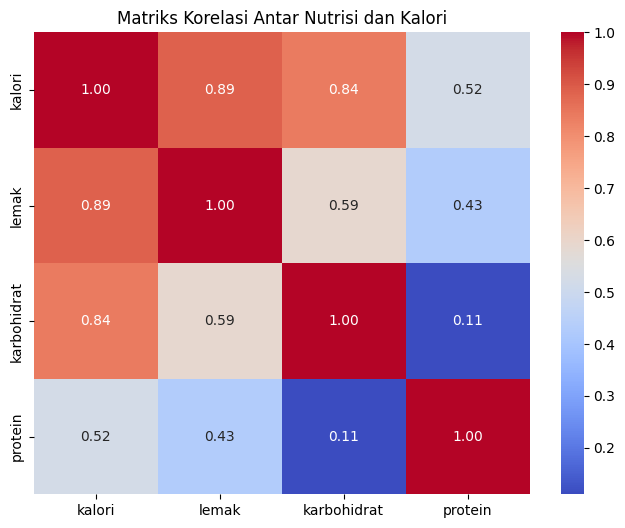

In [ ]:
correlation_matrix = nutrisi[['kalori', 'lemak', 'karbohidrat', 'protein']].corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Antar Nutrisi dan Kalori')
plt.show()

In [ ]:
# Menentukan ambang batas untuk 'tinggi protein' (15 gram)
protein_target = 15

# Menentukan ambang batas untuk 'rendah lemak' (5 gram)
fat_target = 5

# Menentukan batas kalori (150 kalori)
calorie_target = 150

print(f"Mencari makanan dengan Protein > {protein_target}g, Lemak < {fat_target}g, dan Kalori < {calorie_target} kalori:")

high_protein_low_calorie_options = nutrisi[
    (nutrisi['protein'] > protein_target) &
    (nutrisi['lemak'] < fat_target) &
    (nutrisi['kalori'] < calorie_target)
].sort_values(by=['protein', 'kalori'], ascending=[False, True])

display(high_protein_low_calorie_options.head(10))

Mencari makanan dengan Protein > 15g, Lemak < 5g, dan Kalori < 150 kalori:


,nama,kalori,lemak,karbohidrat,protein
50,Ikan Nila Goreng,128,2.65,0.0,26.15
43,Ikan Bawal Goreng,113,2.69,0.0,20.78
64,Kepiting,101,1.76,0.0,20.03
42,Lele Goreng,105,2.85,0.0,18.47
53,Pepes Tongkol,105,1.27,7.1,15.93
54,Cumi Goreng,125,2.17,9.9,15.13


### Insight:
1. **Dampak Masif Lemak terhadap Kalori**: *Scatter plot* antara `lemak` dan `kalori` menunjukkan pola linear positif yang sangat rapat dan kuat. Tren ini mengonfirmasi secara empiris bahwa kandungan lemak merupakan prediktor atau faktor utama yang paling sensitif dalam menentukan tinggi rendahnya total kalori suatu hidangan di dalam dataset.
2. **Karakteristik Sebaran Karbohidrat**: Hubungan antara `karbohidrat` dan `kalori` menunjukkan korelasi positif tingkat moderat dengan sebaran data yang lebih bervariasi. Visualisasi ini berhasil memetakan dua klaster ekstrem:
   * **Klaster Gula/Pati Rendah**: Penumpukan data di sepanjang garis vertikal `0g` karbohidrat yang tetap memiliki kalori substansial (klaster protein dan lemak hewani murni).
   * **Klaster Energi Padat**: Makanan di atas rentang 40g karbohidrat yang linear dengan lonjakan kalori tinggi (klaster makanan pokok porsi besar dan olahan mi).
3. **Konfirmasi Outlier Bersama**: Kedua grafik secara visual sukses mengisolasi titik pencilan ekstrem yang konsisten berada di pojok kanan atas grafik (Kalori > 600 kkal), yang didorong oleh tingginya kadar lemak (>20g) sekaligus karbohidrat (>70g) secara bersamaan.

## Menyiapkan Data

In [ ]:
nutrisi.to_csv('Dataset Nutrisi Makanan.csv', index = False)